In [56]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 

In [57]:
output_paths = Path("binaural_eval/word_task_voice_loc_cue").glob("*.pkl")


In [58]:
results_dfs = []
for path in output_paths:
    res_dict = pickle.load(open(path, 'rb'))
    for cond, meta in res_dict.items():
        # reformat dict
        record = {}
        record['sex_pairing'] = cond
        record['target_azim'] = meta['target_loc'][0]
        record['target_elev'] = meta['target_loc'][1]
        record['distractor_azim'] = meta['distract_loc'][0]
        record['distractor_elev'] = meta['distract_loc'][1]
        record['word_acc'] = meta['results'][0]
        record['word_error'] = meta['results'][1]
        record['confusions'] = meta['confusions'][0]
        record['confusion_error'] = meta['confusions'][1]

        df = pd.DataFrame.from_records([record])
        results_dfs.append(df)
results = pd.concat(results_dfs)

In [59]:
remap_azim = lambda azim: 360 - azim if azim > 90 else 0 - azim 

results['target_azim'] = results['target_azim'].apply(remap_azim)
results['distractor_azim'] = results['distractor_azim'].apply(remap_azim)

In [60]:
results

,sex_pairing,target_azim,target_elev,distractor_azim,distractor_elev,word_acc,word_error,confusions,confusion_error
0,m_m,0,0,0,0,0.152091,0.012793,0.077313,0.009515
0,m_f,0,0,0,0,0.168568,0.013336,0.057034,0.008261
0,f_m,0,0,0,0,0.134347,0.012149,0.073511,0.009297
0,f_f,0,0,0,0,0.141952,0.012433,0.077313,0.009515
0,m_m,0,0,-10,0,0.168568,0.013336,0.049430,0.007722
...,...,...,...,...,...,...,...,...,...
0,f_f,-90,0,-80,0,0.215463,0.014646,0.070976,0.009148
0,m_m,-90,0,-90,0,0.211660,0.014552,0.095057,0.010448
0,m_f,-90,0,-90,0,0.269962,0.015815,0.063371,0.008679
0,f_m,-90,0,-90,0,0.211660,0.014552,0.074778,0.009370


In [61]:
sex_map = {'m_m':'same', "m_f":'diff', 'f_m':'diff', 'f_f':'same'}
results['sex_cond'] = results.sex_pairing.map(sex_map)

In [62]:
results[results.sex_cond == 'same'].sex_pairing.unique()

array(['m_m', 'f_f'], dtype=object)

In [63]:
results[results.sex_cond == 'diff'].sex_pairing.unique()

array(['m_f', 'f_m'], dtype=object)

In [64]:
results.groupby(["target_azim", "distractor_azim"]).mean()

target_elev  distractor_elev  word_acc  \
target_azim distractor_azim                                           
-90         -90                      0.0              0.0  0.217997   
            -80                      0.0              0.0  0.250634   
            -70                      0.0              0.0  0.259189   
            -60                      0.0              0.0  0.269645   
            -50                      0.0              0.0  0.282636   
...                                  ...              ...       ...   
 90          50                      0.0              0.0  0.186946   
             60                      0.0              0.0  0.178707   
             70                      0.0              0.0  0.173954   
             80                      0.0              0.0  0.166984   
             90                      0.0              0.0  0.168568   

                             word_error  confusions  confusion_error  
target_azim distractor_azim                                           
-90         -90                0.014641    0.085868         0.009914  
            -80                0.015358    0.056717         0.008213  
            -70                0.015528    0.049113         0.007584  
            -60                0.015738    0.039607         0.006901  
            -50                0.015982    0.045627         0.007345  
...                                 ...         ...              ...  
 90          50                0.013848    0.070342         0.009074  
             60                0.013611    0.072243         0.009181  
             70                0.013480    0.077947         0.009533  
             80                0.013225    0.076996         0.009483  
             90                0.013292    0.074461         0.009331  

[361 rows x 6 columns]

In [65]:
diff_sex

,sex_pairing,target_azim,target_elev,distractor_azim,distractor_elev,word_acc,word_error,confusions,confusion_error,sex_cond
0,m_f,0,0,0,0,0.168568,0.013336,0.057034,0.008261,diff
0,f_m,0,0,0,0,0.134347,0.012149,0.073511,0.009297,diff
0,m_f,0,0,10,0,0.201521,0.014290,0.043093,0.007234,diff
0,f_m,0,0,10,0,0.157161,0.012965,0.046895,0.007531,diff
0,m_f,0,0,20,0,0.215463,0.014646,0.034221,0.006476,diff
...,...,...,...,...,...,...,...,...,...,...
0,f_m,90,0,70,0,0.249683,0.015419,0.034221,0.006476,diff
0,m_f,90,0,80,0,0.315589,0.016556,0.046895,0.007531,diff
0,f_m,90,0,80,0,0.225602,0.014890,0.055767,0.008175,diff
0,m_f,90,0,90,0,0.269962,0.015815,0.063371,0.008679,diff


In [66]:
diff_sex_acc

target_azim  distractor_azim
0            0                  0.151458
             10                 0.179341
             20                 0.207224
             30                 0.255387
             40                 0.259823
                                  ...   
350          310                0.242079
             320                0.225602
             330                0.197085
             340                0.155894
             350                0.149556
Name: word_acc, Length: 361, dtype: float64

In [67]:
same_sex_acc

target_azim  distractor_azim
0            0                  0.147022
             10                 0.159062
             20                 0.193916
             30                 0.235108
             40                 0.249683
                                  ...   
350          310                0.217364
             320                0.210393
             330                0.176806
             340                0.157795
             350                0.149556
Name: word_acc, Length: 361, dtype: float64

array([<AxesSubplot:xlabel='distractor_azim', ylabel='target_azim'>,
       <AxesSubplot:xlabel='distractor_azim', ylabel='target_azim'>,
       <AxesSubplot:xlabel='distractor_azim', ylabel='target_azim'>,
       <AxesSubplot:xlabel='distractor_azim', ylabel='target_azim'>,
       <AxesSubplot:xlabel='distractor_azim', ylabel='target_azim'>,
       <AxesSubplot:xlabel='distractor_azim', ylabel='target_azim'>],
      dtype=object)

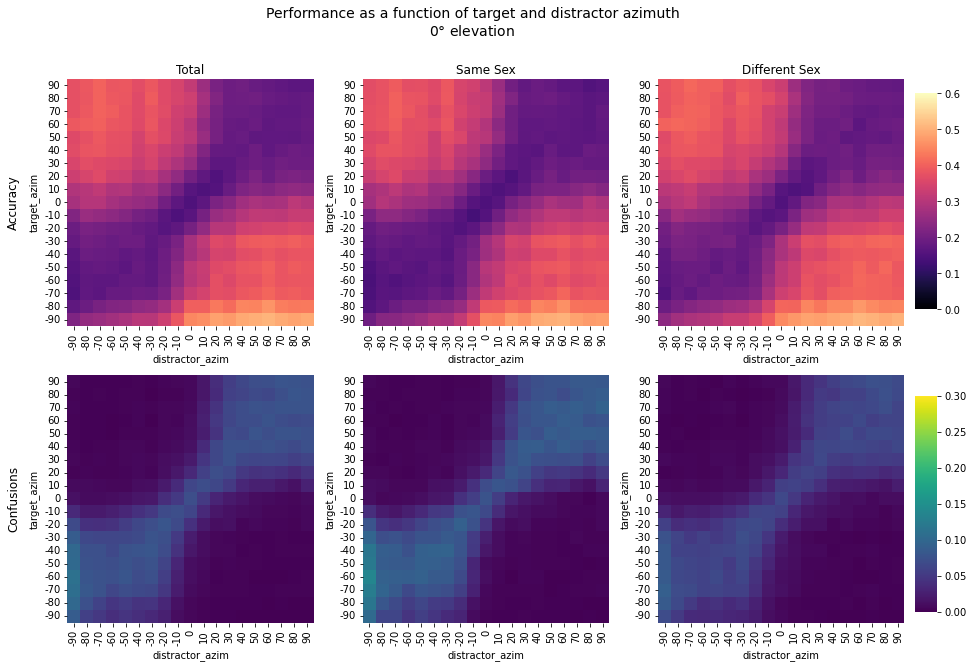

In [109]:
# plot all plots so far onto one figure
cols = ['Total', 'Same Sex', 'Different Sex']
rows = ['Accuracy', 'Confusions']

fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex=False, sharey=False)

cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

total_acc = results.groupby(["target_azim", "distractor_azim"]).mean()['word_acc']
sns.heatmap(total_acc.unstack(), vmin=0, vmax=0.6, cmap='magma', cbar=True, cbar_ax=cbar_ax_1, ax=axs[0, 0])
total_con = results.groupby(['target_azim', 'distractor_azim']).mean()['confusions']
sns.heatmap(total_con.unstack(), vmin=0, vmax=0.3, cmap='viridis', cbar=True, cbar_ax=cbar_ax_2, ax=axs[1, 0])

same_sex = results[results.sex_cond == 'same']
same_sex_acc = same_sex.groupby(['target_azim', 'distractor_azim'])['word_acc'].mean()
sns.heatmap(same_sex_acc.unstack(), vmin=0, vmax= 0.6, cmap='magma', cbar=False, cbar_ax=None, ax=axs[0, 1])
same_sex_con = same_sex.groupby(['target_azim', 'distractor_azim'])['confusions'].mean()
sns.heatmap(same_sex_con.unstack(), vmin=0, vmax=0.3, cmap='viridis', cbar=False, cbar_ax=None, ax=axs[1, 1])

diff_sex = results[results.sex_cond == 'diff']
diff_sex_acc = diff_sex.groupby(['target_azim', 'distractor_azim'])['word_acc'].mean()
sns.heatmap(diff_sex_acc.unstack(), vmin=0, vmax=0.6, cmap='magma', cbar=False, cbar_ax=None, ax=axs[0, 2])
diff_sex_con = diff_sex.groupby(['target_azim', 'distractor_azim'])['confusions'].mean()
sns.heatmap(diff_sex_con.unstack(), vmin=0, vmax=0.3, cmap='viridis', cbar=False, cbar_ax=None, ax=axs[1, 2])

for ax, col in zip(axs[0], cols):
    ax.annotate(col, xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
for ax, row in zip(axs[:, 0], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# fig.tight_layout(rect=[0,0,.9,1])
plt.suptitle('Performance as a function of target and distractor azimuth\n$0\degree$ elevation', fontsize=14, y=0.98);

for ax in axs.flatten():
    ax.invert_yaxis()
